### Feature Engineering for CTR Prediction
# 
#### **Author**: Praveen Kumar  
#### **Date**: September 2026
# 
#### Creating meaningful features to improve model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load processed data
df = pd.read_csv('../data/processed_data.csv')
print(f"Original dataset shape: {df.shape}")
df.head()

Original dataset shape: (10000, 9)


,Age,Income,Time_on_Site,Previous_Clicks,Device_Type,Ad_Category,Gender,Time_of_Day,Clicked
0,-0.270336,-1.067872,1.723546,-3.414406,0.031394,-1.269845,3.612138,2.761570,1
1,1.417750,-2.044457,2.360961,-0.057302,-1.798305,0.801589,1.666972,0.961546,0
2,-0.250326,-0.996390,-2.254302,2.339306,-0.119648,-0.402036,-1.361081,-0.491140,0
3,-1.350838,0.698667,2.210836,-4.490122,-0.034687,-1.723581,3.160316,1.134817,1
4,-0.749040,-0.832755,-0.287085,1.682244,-3.172607,1.269722,2.529730,-0.248268,1


In [3]:
# Create new features
df_fe = df.copy()

In [4]:
# 1. Age groups (bucketing)
df_fe['Age_Group'] = pd.cut(df_fe['Age'], 
                            bins=[0, 25, 35, 45, 55, 100], 
                            labels=['18-25', '26-35', '36-45', '46-55', '55+'])

In [5]:
# 2. Income brackets
df_fe['Income_Bracket'] = pd.cut(df_fe['Income'], 
                                 bins=[0, 40000, 60000, 80000, 100000, 200000],
                                 labels=['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High'])

In [6]:
# 3. Engagement score (combination of time and previous clicks)
df_fe['Engagement_Score'] = df_fe['Time_on_Site'] * 0.3 + df_fe['Previous_Clicks'] * 0.7

In [7]:
# 4. Is_Active_User (if previous clicks > 20)
df_fe['Is_Active_User'] = (df_fe['Previous_Clicks'] > 20).astype(int)

In [8]:
# 5. Is_High_Income (Income > 80000)
df_fe['Is_High_Income'] = (df_fe['Income'] > 80000).astype(int)

In [9]:
# 6. Time_Previous_Clicks_Interaction
df_fe['Time_Clicks_Interaction'] = df_fe['Time_on_Site'] * df_fe['Previous_Clicks']

In [10]:
# 7. Age_Income_Interaction (age and income combo)
df_fe['Age_Income_Ratio'] = df_fe['Age'] / (df_fe['Income'] / 1000)

In [11]:
# 8. Device type as numeric
df_fe['Device_Type_Num'] = (df_fe['Device_Type'] == 'Mobile').astype(int)

In [12]:
# 9. Time of day features
df_fe['Is_Evening'] = (df_fe['Time_of_Day'] == 'Evening').astype(int)
df_fe['Is_Morning'] = (df_fe['Time_of_Day'] == 'Morning').astype(int)

In [13]:
# 10. Ad category features
df_fe['Is_Tech_Ad'] = (df_fe['Ad_Category'] == 'Technology').astype(int)
df_fe['Is_Lifestyle_Ad'] = (df_fe['Ad_Category'] == 'Lifestyle').astype(int)

In [14]:
# 11. Gender
df_fe['Is_Male'] = (df_fe['Gender'] == 'Male').astype(int)
df_fe['Is_Female'] = (df_fe['Gender'] == 'Female').astype(int)

In [15]:
print(f"After feature engineering: {df_fe.shape}")
df_fe.head()

After feature engineering: (10000, 23)


,Age,Income,Time_on_Site,Previous_Clicks,Device_Type,Ad_Category,Gender,Time_of_Day,Clicked,Age_Group,...,Is_High_Income,Time_Clicks_Interaction,Age_Income_Ratio,Device_Type_Num,Is_Evening,Is_Morning,Is_Tech_Ad,Is_Lifestyle_Ad,Is_Male,Is_Female
0,-0.270336,-1.067872,1.723546,-3.414406,0.031394,-1.269845,3.612138,2.761570,1,NaN,...,0,-5.884886,253.154016,0,0,0,0,0,0,0
1,1.417750,-2.044457,2.360961,-0.057302,-1.798305,0.801589,1.666972,0.961546,0,18-25,...,0,-0.135288,-693.460381,0,0,0,0,0,0,0
2,-0.250326,-0.996390,-2.254302,2.339306,-0.119648,-0.402036,-1.361081,-0.491140,0,NaN,...,0,-5.273503,251.233069,0,0,0,0,0,0,0
3,-1.350838,0.698667,2.210836,-4.490122,-0.034687,-1.723581,3.160316,1.134817,1,NaN,...,0,-9.926921,-1933.449131,0,0,0,0,0,0,0
4,-0.749040,-0.832755,-0.287085,1.682244,-3.172607,1.269722,2.529730,-0.248268,1,NaN,...,0,-0.482947,899.472758,0,0,0,0,0,0,0


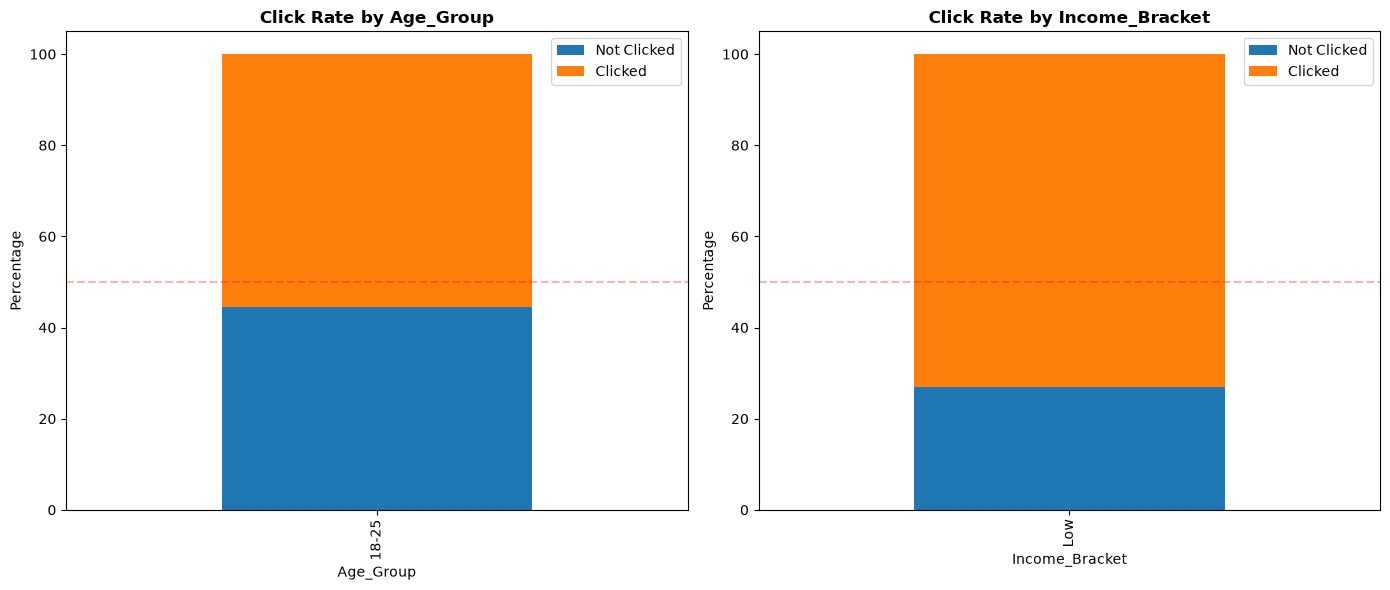

In [16]:
# Check distribution of new features
new_categorical = ['Age_Group', 'Income_Bracket']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.ravel()

for idx, col in enumerate(new_categorical):
    ax = axes[idx]
    crosstab = pd.crosstab(df_fe[col], df_fe['Clicked'], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'Click Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage')
    ax.legend(['Not Clicked', 'Clicked'])
    ax.axhline(y=50, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

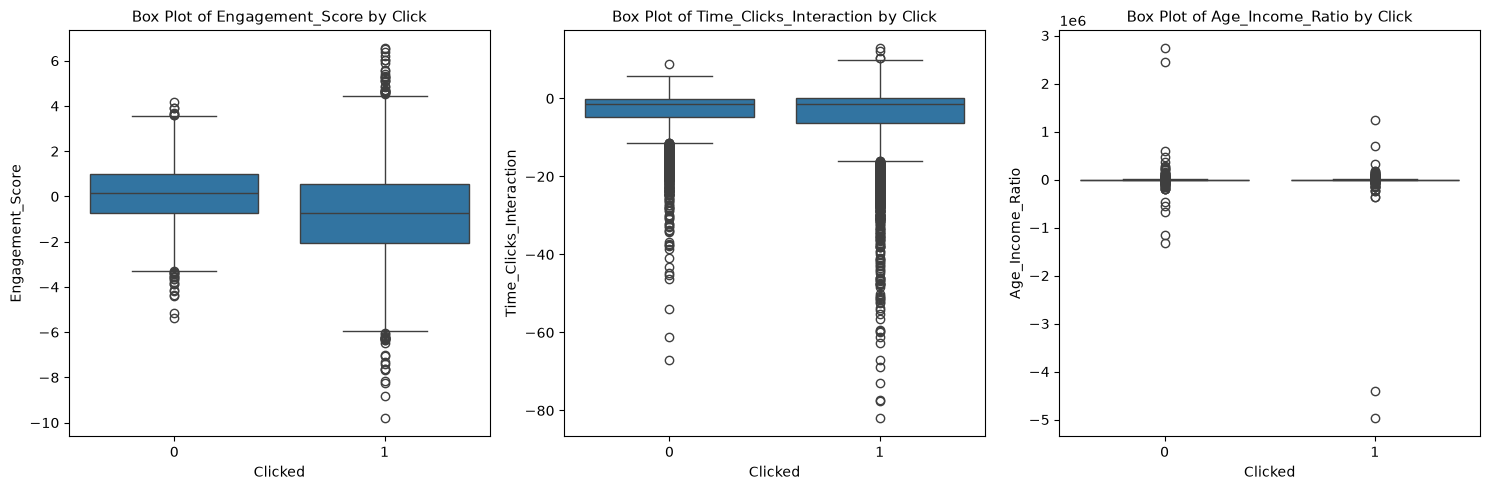

In [17]:
# Analyze new numerical features
new_numerical = ['Engagement_Score', 'Time_Clicks_Interaction', 'Age_Income_Ratio']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for idx, col in enumerate(new_numerical):
    ax = axes[idx]
    sns.boxplot(data=df_fe, y=col, x='Clicked', ax=ax)
    ax.set_title(f'Box Plot of {col} by Click', fontsize=11)
    ax.set_xlabel('Clicked')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [18]:
# Correlation with target
target_corr = df_fe.select_dtypes(include=[np.number]).corr()['Clicked'].sort_values(ascending=False)
print("Top features correlated with Click:")
print(target_corr.head(15))

Top features correlated with Click:
Clicked                    1.000000
Income                     0.506664
Gender                     0.322822
Device_Type                0.280768
Time_of_Day                0.143571
Time_on_Site               0.009259
Age                        0.005436
Ad_Category               -0.005626
Age_Income_Ratio          -0.015493
Time_Clicks_Interaction   -0.083097
Previous_Clicks           -0.214433
Engagement_Score          -0.255238
Is_Active_User                  NaN
Is_High_Income                  NaN
Device_Type_Num                 NaN
Name: Clicked, dtype: float64


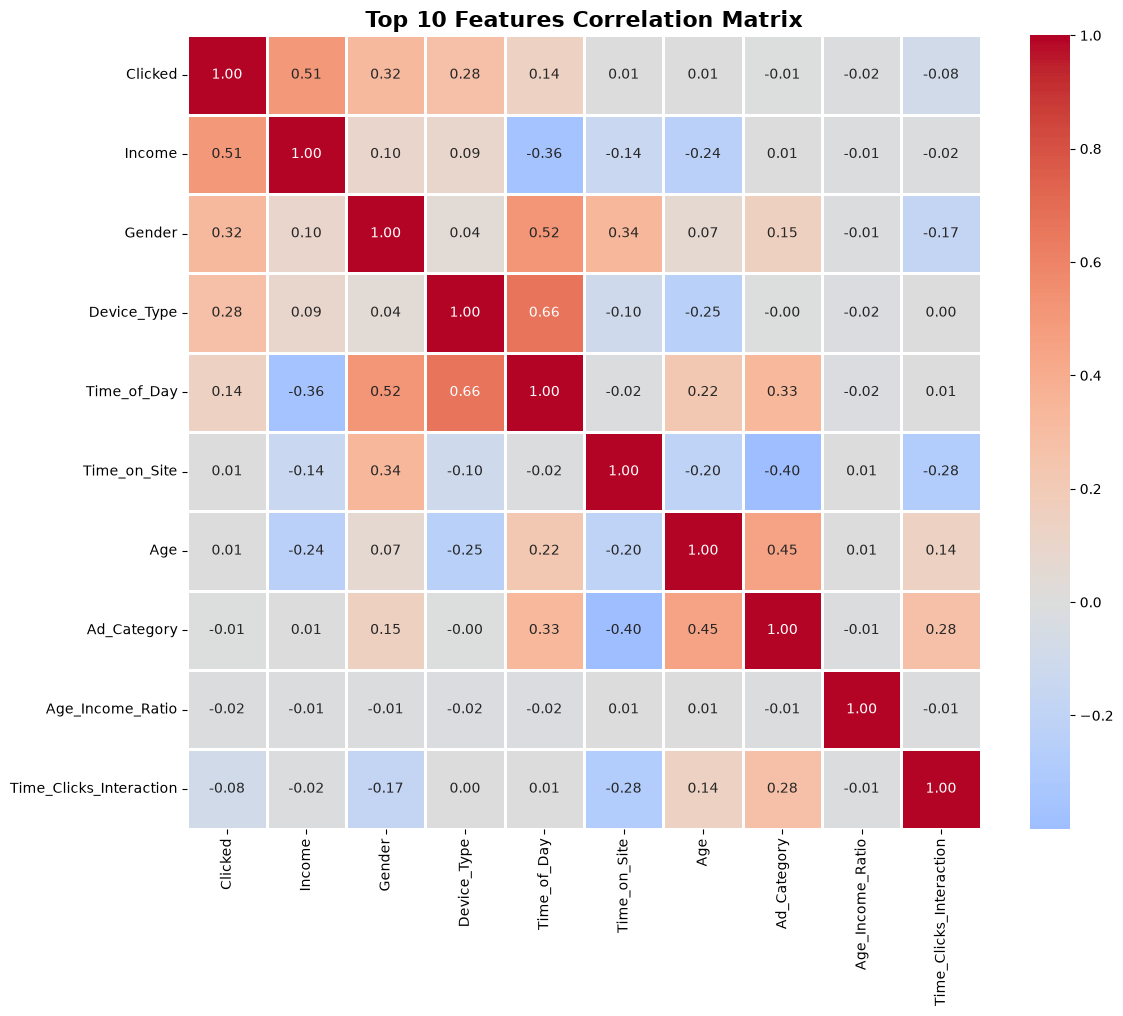

In [19]:
# Plot top correlations
top_features = target_corr.head(10).index
corr_data = df_fe[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Top 10 Features Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Prepare final dataset for modeling
# Select features to keep (both original and engineered)
features_to_keep = [
    'Age', 'Income', 'Time_on_Site', 'Previous_Clicks',
    'Device_Type_Num', 'Is_Tech_Ad', 'Is_Male', 'Is_Evening',
    'Engagement_Score', 'Is_Active_User', 'Is_High_Income',
    'Time_Clicks_Interaction', 'Age_Income_Ratio'
]

X = df_fe[features_to_keep]
y = df_fe['Clicked']

print("Features selected for modeling:")
print(X.columns.tolist())

Features selected for modeling:
['Age', 'Income', 'Time_on_Site', 'Previous_Clicks', 'Device_Type_Num', 'Is_Tech_Ad', 'Is_Male', 'Is_Evening', 'Engagement_Score', 'Is_Active_User', 'Is_High_Income', 'Time_Clicks_Interaction', 'Age_Income_Ratio']


In [21]:
# Scale numerical features
numerical_to_scale = ['Age', 'Income', 'Time_on_Site', 'Previous_Clicks', 
                      'Engagement_Score', 'Time_Clicks_Interaction', 'Age_Income_Ratio']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_to_scale] = scaler.fit_transform(X[numerical_to_scale])

In [22]:
# Save processed data
import joblib
import os
os.makedirs('../models', exist_ok=True)

# Save the scaler
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [23]:
# Save feature names
with open('../models/feature_names.txt', 'w') as f:
    for feature in features_to_keep:
        f.write(f"{feature}\n")

In [24]:
# Save final dataset
final_df = pd.concat([X_scaled, y], axis=1)
final_df.to_csv('../data/final_data.csv', index=False)

print("Feature engineering complete!")
print(f"Final dataset shape: {final_df.shape}")
print("Saved to 'data/final_data.csv'")

Feature engineering complete!
Final dataset shape: (10000, 14)
Saved to 'data/final_data.csv'


In [25]:
# Summary of feature engineering
print("\n=== Feature Engineering Summary ===")
print(f"Original features: {df.shape[1]}")
print(f"Final features: {X.shape[1]}")
print(f"New features created: {X.shape[1] - df.shape[1] + 1}")
print("\nTop 5 most important features (by correlation):")
for feature in target_corr.head(5).index:
    if feature in X.columns:
        print(f"- {feature}: {target_corr[feature]:.3f}")


=== Feature Engineering Summary ===
Original features: 9
Final features: 13
New features created: 5

Top 5 most important features (by correlation):
- Income: 0.507
